# FPR Experiment for Adaptive CoRT-SI

This notebook estimates the false positive rate (FPR) under the null by setting the target coefficient to zero. It runs 100 datasets, draws one random selected feature per dataset through `SI_randj(...)`, evaluates rejection at the fixed level $\alpha = 0.05$, and compares the null p-value histogram to the uniform reference.

In [6]:
# # For kaggle:
# !git clone https://github.com/maTiahK/CORT_SI.git
# %cd /kaggle/working/CORT_SI

# !python -m pip install -q --upgrade pip
# !python -m pip install -q -e .


# from cort_si import SI, SI_randj, gen_data
# print("CORT_SI import OK")

In [7]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
REPO_ROOT = next((candidate for candidate in candidates if (candidate / "cort_si").exists()), None)
if REPO_ROOT is None:
    raise RuntimeError("Could not locate the repo root containing the cort_si package.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from cort_si import SI_randj, gen_data

RESULTS_DIR = REPO_ROOT / "run_experiment" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
p = 300
nS = 100
num_info_aux = 3
num_uninfo_aux = 2
K = num_info_aux + num_uninfo_aux
lambda_sel = 0.4
lambda0 = 0.5
T = 3
nT_list = [50, 75, 100]

num_runs = 50
seed = 0

alpha = 0.05
true_beta_scale = 0.0
rho = 0.0
sigma_noise = 1.0
source_shift_sd = 0.3
covariate_shift = False

print(f"num_runs = {num_runs}")
print(f"fixed alpha = {alpha}")
print(f"Null model true_beta scale = {true_beta_scale}")
print(f"K = {K}, p = {p}, nS = {nS}, nT = {nT}")

num_runs = 50
fixed alpha = 0.05
Null model true_beta scale = 0.0
K = 2, p = 100, nS = 50, nT = 30


In [ ]:
def generate_null_instance(iteration_seed):
    return gen_data.generate_data(
        p=p,
        nS=nS,
        nT=nT,
        K=K,
        true_beta=true_beta_scale,
        rho=rho,
        sigma_noise=sigma_noise,
        source_shift_sd=source_shift_sd,
        covariate_shift=covariate_shift,
        seed=iteration_seed,
    )


def summarize_fpr_at_alpha(pvalues, alpha):
    if pvalues.size == 0:
        return np.array([], dtype=float), np.array([], dtype=float)

        
    rejection_indicators = (pvalues <= alpha).astype(float)
    running_fpr = np.cumsum(rejection_indicators) / np.arange(1, rejection_indicators.size + 1)
    return rejection_indicators, running_fpr


def run_fpr_experiment(num_runs, seed):
    null_pvalues = []

    for iteration in range(num_runs):
        data_seed = seed + iteration
        XS_list, YS_list, X0, Y0, _, SigmaS_list, Sigma0, _ = generate_null_instance(data_seed)
        lambdak_list = [lambda0] * len(XS_list)

        pvalue = SI_randj(
            X0,
            Y0,
            XS_list,
            YS_list,
            lambda_sel=lambda_sel,
            lambda0=lambda0,
            lambdak_list=lambdak_list,
            SigmaS_list=SigmaS_list,
            Sigma0=Sigma0,
            T=T,
            verbose=False,
        )

        if pvalue is not None and np.isfinite(pvalue):
            null_pvalues.append(float(pvalue))

        if (iteration + 1) % 10 == 0:
            print(f"Completed {iteration + 1}/{num_runs} runs")

    return np.asarray(null_pvalues, dtype=float)

In [10]:
null_pvalues = run_fpr_experiment(num_runs=num_runs, seed=seed)
rejection_indicators, running_fpr = summarize_fpr_at_alpha(null_pvalues, alpha)

fpr_path = RESULTS_DIR / "fpr_results.npz"
np.savez(
    fpr_path,
    null_pvalues=null_pvalues,
    rejection_indicators=rejection_indicators,
    running_fpr=running_fpr,
    alpha=np.asarray([alpha], dtype=float),
    num_runs=np.asarray([num_runs], dtype=int),
)

print(f"Saved FPR results to {fpr_path}")
print(f"Valid null p-values collected: {null_pvalues.size}/{num_runs}")
if rejection_indicators.size > 0:
    print(f"Empirical FPR at alpha={alpha:.2f}: {rejection_indicators.mean():.3f}")

Completed 10/50 runs
Completed 20/50 runs
Completed 30/50 runs
Completed 40/50 runs
Completed 50/50 runs
Saved FPR results to C:\Users\Legion\Documents\SI For CoRT\CORT_SI\run_experiment\results\fpr_results.npz
Valid null p-values collected: 44/50
Empirical FPR at alpha=0.05: 0.045


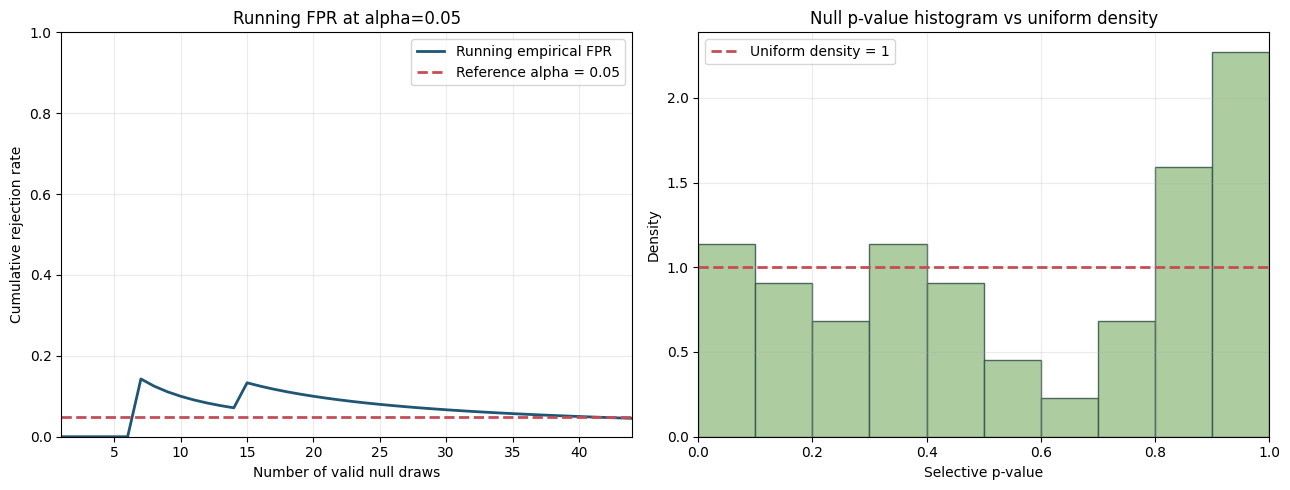

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

if running_fpr.size > 0:
    draw_index = np.arange(1, running_fpr.size + 1)
    axes[0].plot(draw_index, running_fpr, color="#1f5673", linewidth=2, label="Running empirical FPR")
    axes[0].axhline(alpha, color="#c44d58", linestyle="--", linewidth=2, label=f"Reference alpha = {alpha:.2f}")
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, "No valid null p-values", ha="center", va="center", transform=axes[0].transAxes)

axes[0].set_title(f"Running FPR at alpha={alpha:.2f}")
axes[0].set_xlabel("Number of valid null draws")
axes[0].set_ylabel("Cumulative rejection rate")
axes[0].set_xlim(1, max(1, running_fpr.size))
axes[0].set_ylim(0.0, 1.0)
axes[0].grid(alpha=0.25)

axes[1].hist(null_pvalues, bins=np.linspace(0.0, 1.0, 11), density=True, color="#9fc490", edgecolor="#35524a", alpha=0.85)
axes[1].axhline(1.0, color="#c44d58", linestyle="--", linewidth=2, label="Uniform density = 1")
axes[1].set_title("Null p-value histogram vs uniform density")
axes[1].set_xlabel("Selective p-value")
axes[1].set_ylabel("Density")
axes[1].set_xlim(0.0, 1.0)
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()